# Run this cell first

In [ ]:
# this code enables the automated feedback. If you remove this, you won't get any feedback
# so don't delete this cell!
try:
  import AutoFeedback
except (ModuleNotFoundError, ImportError):
  %pip install AutoFeedback
  import AutoFeedback

try:
  from testsrc import test_main
except (ModuleNotFoundError, ImportError):
  %pip install "git+https://github.com/autofeedback-exercises/exercises.git#subdirectory=MTH2100/numerical_analysis/root_finding"
  from testsrc import test_main

def runtest(tlist):
  import unittest
  from contextlib import redirect_stderr
  from os import devnull
  with redirect_stderr(open(devnull, 'w')):
    suite = unittest.TestSuite()
    for tname in tlist:
      suite.addTest(eval(f"test_main.UnitTests.{tname}"))
    runner = unittest.TextTestRunner()
    try:
      runner.run(suite)
    except (AssertionError, ImportError):
      pass

# 2. Root Finding

## Why this matters

Many modelling problems reduce to: *find $x$ such that $f(x) = 0$*. Examples include:
- Finding equilibrium states of a population model
- Matching a model prediction to observed data
- Inverting a numerical solution (e.g. "at what time does the epidemic peak?")

Analytical solutions rarely exist; we need iterative numerical methods.

**Learning objectives**
- Implement the bisection method and understand why it always converges
- Implement Newton–Raphson and understand its quadratic convergence
- Compare the two methods and know when each is preferable
- Apply root finding to locate equilibria and stability boundaries in a mathematical model

<div style="background:#e8f4f8;border-left:4px solid #2196F3;padding:16px;margin:16px 0;border-radius:4px;">

**📹 VIDEO: Root Finding: Bisection and Newton–Raphson**

*What this video covers:* The root-finding problem; convergence and order of convergence; the bisection method and why it is guaranteed to converge; Newton–Raphson and its geometric interpretation; linear vs quadratic convergence; when Newton–Raphson can fail.

*(Embed the video here using an `<iframe>` or `IPython.display.Video`)*
</div>

## 1. The Root-Finding Problem

Given a continuous function $f : \mathbb{R} \to \mathbb{R}$, find $p$ such that $f(p) = 0$.

### Bisection method

If $f(a) \cdot f(b) < 0$ (i.e. $f$ changes sign on $[a,b]$), the **intermediate value
theorem** guarantees a root. The bisection method exploits this by halving the interval
repeatedly:

$$c = \frac{a+b}{2}, \quad \text{then replace } [a,b] \text{ with } [a,c] \text{ or } [c,b]
\text{ depending on sign}$$

**Convergence:** after $n$ steps the error satisfies $|p_n - p| \leq \dfrac{b-a}{2^n}$.
This is **linear convergence** (error halves each step).

### Newton–Raphson method

Starting from an initial guess $p_0$, each iteration follows the tangent line to the root:

$$p_{n+1} = p_n - \frac{f(p_n)}{f'(p_n)}$$

**Convergence:** near a simple root, Newton–Raphson has **quadratic convergence** —
the number of correct digits roughly doubles with each step.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({'font.size': 12, 'figure.dpi': 100})

# ════════════════════════════════════════════════════════════════
# BISECTION METHOD
# ════════════════════════════════════════════════════════════════

def bisection(f, a, b, tol=1e-10, max_iter=100):
    '''
    Find a root of f in [a, b] using the bisection method.

    Parameters
    ----------
    f        : callable  — the function
    a, b     : floats    — bracket endpoints, must satisfy f(a)*f(b) < 0
    tol      : float     — stop when |b - a| < tol
    max_iter : int       — maximum number of iterations

    Returns
    -------
    root     : float     — approximate root
    history  : list      — midpoint at each iteration (for convergence analysis)
    '''
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs.")

    history = []
    for _ in range(max_iter):
        c = (a + b) / 2          # midpoint
        history.append(c)        # record for analysis

        if abs(b - a) < tol:     # bracket is small enough: stop
            break

        if f(a) * f(c) < 0:      # root is in left half
            b = c
        else:                    # root is in right half
            a = c

    return c, history

# ── Demo on f(x) = x^3 - 2x - 5 ─────────────────────────────────────────────
# One real root near x = 2 (can verify: f(2) = -1, f(3) = 16)
def f_demo(x):
    return x**3 - 2*x - 5

root_bi, hist_bi = bisection(f_demo, a=2.0, b=3.0)
print(f"Bisection root: {root_bi:.10f}")
print(f"f(root)       : {f_demo(root_bi):.2e}  (should be ≈ 0)")
print(f"Iterations    : {len(hist_bi)}")

Bisection root: 2.0945514816
f(root)       : 2.92e-10  (should be ≈ 0)
Iterations    : 35


In [3]:
# ════════════════════════════════════════════════════════════════
# NEWTON–RAPHSON METHOD
# ════════════════════════════════════════════════════════════════

def newton_raphson(f, df, x0, tol=1e-10, max_iter=50):
    '''
    Find a root of f using Newton-Raphson iteration.

    Parameters
    ----------
    f, df    : callables — function and its derivative
    x0       : float     — initial guess
    tol      : float     — stop when |f(x)| < tol
    max_iter : int       — maximum iterations

    Returns
    -------
    root    : float — approximate root
    history : list  — successive iterates (for convergence analysis)
    '''
    x = x0
    history = [x]
    for _ in range(max_iter):
        fx = f(x)
        if abs(fx) < tol:        # close enough to zero: stop
            break
        dfx = df(x)
        if dfx == 0:
            raise ZeroDivisionError("Derivative is zero — Newton-Raphson fails here.")
        x = x - fx / dfx        # Newton-Raphson update
        history.append(x)
    return x, history

# Derivative of f(x) = x^3 - 2x - 5  is  f'(x) = 3x^2 - 2
def df_demo(x):
    return 3 * x**2 - 2

root_nr, hist_nr = newton_raphson(f_demo, df_demo, x0=3.0)
print(f"Newton-Raphson root: {root_nr:.10f}")
print(f"f(root)            : {f_demo(root_nr):.2e}")
print(f"Iterations         : {len(hist_nr)}")

Newton-Raphson root: 2.0945514815
f(root)            : 2.33e-13
Iterations         : 6


True root (via numpy.roots): 2.0945514815


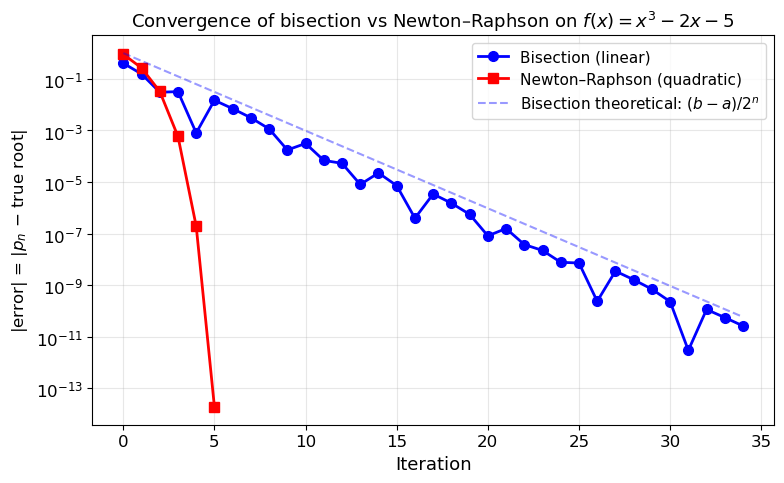

Newton-Raphson reaches machine precision in ~6 iterations.
Bisection takes ~35 iterations to reach the same accuracy.
But bisection is guaranteed to converge; Newton-Raphson is not.


In [4]:
# ── Convergence comparison ────────────────────────────────────────────────────
# Plot |error| vs iteration for both methods.
# We need the "true" root; numpy can find it for us.
true_root = np.roots([1, 0, -2, -5])[np.isreal(np.roots([1, 0, -2, -5]))].real[0]
print(f"True root (via numpy.roots): {true_root:.10f}")

err_bi = [abs(x - true_root) for x in hist_bi]
err_nr = [abs(x - true_root) for x in hist_nr]

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(err_bi, 'bo-', lw=2, ms=7, label='Bisection (linear)')
ax.semilogy(err_nr, 'rs-', lw=2, ms=7, label='Newton–Raphson (quadratic)')

# Bisection: error halves each step => reference line with slope -log10(2)
n_ref = np.arange(len(err_bi))
initial_err = abs(3.0 - 2.0)  # initial bracket width
ax.semilogy(n_ref, initial_err / 2**n_ref, 'b--', alpha=0.4, lw=1.5,
            label='Bisection theoretical: $(b-a)/2^n$')

ax.set_xlabel('Iteration', fontsize=13)
ax.set_ylabel('|error| = |$p_n$ − true root|', fontsize=12)
ax.set_title(r'Convergence of bisection vs Newton–Raphson on $f(x)=x^3-2x-5$', fontsize=13)
ax.legend(fontsize=11); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

print("Newton-Raphson reaches machine precision in ~6 iterations.")
print("Bisection takes ~35 iterations to reach the same accuracy.")
print("But bisection is guaranteed to converge; Newton-Raphson is not.")

## 2. Application: Equilibria of a Model

Consider the **logistic population model**:

$$\frac{dN}{dt} = rN\!\left(1 - \frac{N}{K}\right)$$

with
- $\frac{dN}{dt}$: The rate of population growth over time
- $N$: The current population size
- $r$: The maximum per capita growth rate (intrinsic rate of increase)
- $K$: The carrying capacity of the environment

So, if my garden has enough space for 100 weeds (K=100), if every weed produces on average 1 baby weed per day ($r=1$), and I start with just one weed, then I can expect that after only 8 or 9 days, my garden will be full of weeds:

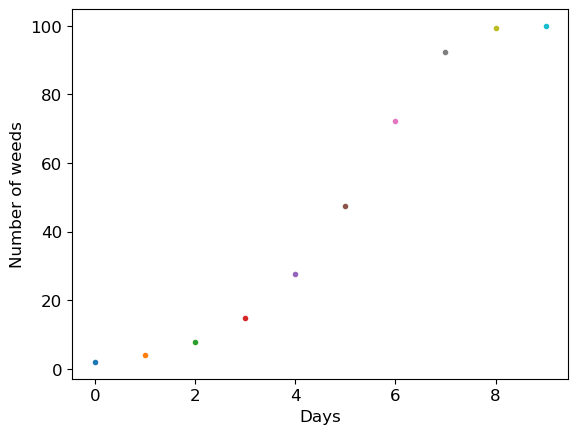

In [5]:
import numpy as np
import matplotlib.pyplot as plt

r = 1
N = 1
K = 100
dt = 1 # the 'time step' is 1 day
for ii in range(10):
    dN = r * N * (1 - N/K) * dt
    N = N + dN
    plt.plot(ii, N, '.')
plt.xlabel('Days')
plt.ylabel('Number of weeds')
plt.show()

Now, **Equilibria** are special values of $N^*$ where $N$ isn't changing. In other words, $N^*$ such that $\frac{dN}{dt}\vert_{N=N^*} = 0$. In this case, I'm interested in equilibria because I am lazy and don't want to spend any time actually doing anything about my garden.

Thus, we have to find **the roots of an equation like** $f(N) = 0$. Now, just by looking at the curve plotted above, or by inspecting the equation, we can see that the roots are ($N^* = 0$ and $N^* = K$). I.E if there are no weeds, or 100 weeds in the garden, then no more will appear (because there are none to reproduce, or no space for any more, respectively). 

That's fine for this simple model. But the true picture is more complex. There might be several different kinds of weeds competing. There might be different weather conditions that change the rate of reproduction. Or, I might start to feel the judgement of my neighbours and go out and pull some weeds. For the more complex models, then, we might need numerical methods.

For example, imagine that I go out into my garden every day and 'harvest' $H$ weeds. We can include that in the model like this:

$$\frac{dN}{dt} = rN\!\left(1 - \frac{N}{K}\right) - H$$

Let's see what that looks like for different values of $H$.

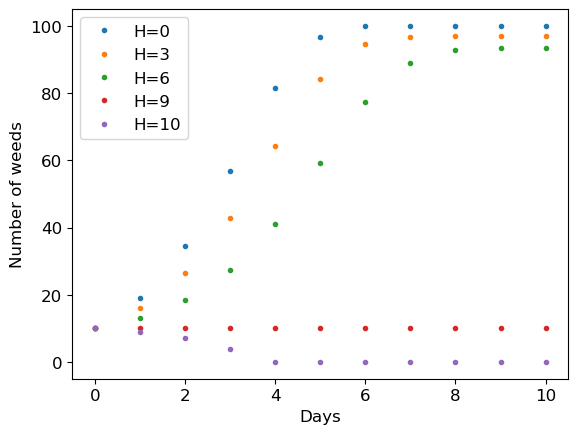

In [6]:
r = 1.0   # intrinsic growth rate
K = 100.0 # carrying capacity
dt = 1 

for H in [0, 3, 6, 9, 10]:
    N = 10 # initial number of weeds 
    weeds = [N]
    for ii in range(10):
        dN = r * N * (1 - N/K) * dt - H
        N =  max(N + dN, 0)
        # We use 'max' here because the minimum number of weeds we could have is 0,
        # without this, we end up with a negative value for N
        weeds.append(N)
    plt.plot(range(11), weeds, '.', label=f'H={H}')
plt.xlabel('Days')
plt.ylabel('Number of weeds')
plt.legend()
plt.show()

For $H=0$ we recover the same behaviour we had before (no harvesting). For small values, $H=3$ and $H=6$, we slow down the proliferation of weeds (slightly) but the number still grows until we get _close to but not quite_ 100. For larger values, $H=9$ and $H=10$ we do in fact stop the spread. $H=10$ corresponds to pulling all the weeds, so although some more are spawned for the first few days, the number decays to zero. For $H=9$, we pull all but one, but the way the equation has encoded the growth means that the next day, 9 more grow, so we always end up with 10 weeds.

To find the equilibrium points, we once again have to find values of $N$ that satisfy $rN(1-N/K) - H = 0$. We'll find those roots using the bisection method we set up earlier.

In [7]:
K=100

# Harvest rate: try changing this value
H_val = 9

def harvest_model(N, H = H_val):
    return r * N * (1 - N / K) - H 

# There are two equilibria: one near N=0, one near N=100
eq1, _ = bisection(harvest_model, a=0.0,  b=50.0)
eq2, _ = bisection(harvest_model, a=50.0, b=100.0)
print(f"H = {H_val}: equilibria at N* = {eq1:.4f} and N* = {eq2:.4f}")

# Verify
print(f"g(N*_1) = {harvest_model(eq1):.2e}")
print(f"g(N*_2) = {harvest_model(eq2):.2e}")

H = 9: equilibria at N* = 10.0000 and N* = 90.0000
g(N*_1) = -7.28e-12
g(N*_2) = -7.28e-12


<div style="background:#e8f4f8;border-left:4px solid #2196F3;padding:16px;margin:16px 0;border-radius:4px;width:100%;box-sizing:border-box;overflow-wrap:break-word;">

**Try putting in different values for H in the code above. What do you notice about the equilibrium values? Do they match with what you would have predicted from the plot above?**

<details style="margin: 1em 0;">
<summary style="cursor:pointer; font-weight:bold; color:#2196F3;">
 Reveal answer
</summary>
<div style="background:#f0f7ff; border-left:4px solid #2196F3; padding:12px 16px; margin-top:8px; border-radius:4px; box-sizing:border-box; overflow-wrap:break-word;">

You might have predicted that for low values of $H$ there would be two equilibrium points, because that's what we saw before. E.G for $H=3$, there are equilibria at $N\approx 3$ and $N\approx 97$. What you might not have predicted, because of the way I plotted the behaviour of the model above, is that for $N=9$ and $N=10$ there are also two equilibrium points. The reason we didn't see them in the plot above is because we only plotted one starting condition ($N=10$), and whereas for the other values of $H$ we 'scanned' through the whole range of $N$ values, for $H=9$ we were already at one equilibrium point ($N=10$) so the population didn't change, and for $H=10$ we killed all the weeds so we didn't 'explore' the higher values of $N$. 

In all cases, if the number of weeds we harvest matches the number of weeds that will grow that day, then we are at an equilibrium point. That's what an equilibrium point is- the point where the system doesn't change. 

The last thing you might have noticed, if you played with it a little more, is that for values of $H\geq 25$, or _negative_ values of $H$ (I guess that means you're actively planting the weeds), the bisection method doesn't work: you don't find a root. The reason for that is that the parameters we have used for the bisection method assume there's one root in the range $0\leq N \leq 50$ and one in the range $50 \leq N \leq 100$. If you set $H$ outside the range $0\leq H < 25$, then that is no longer true, and the bisection method fails. 
</div>
</details></div>

<div style="background:#f7d6e3;border-left:4px solid #f32121;padding:16px;margin:16px 0;border-radius:4px;width:100%;box-sizing:border-box;overflow-wrap:break-word;">

# Exercise

1. Solve the root finding problem for the harvest model using the Newton Raphson method in place of the bisection method. To do that you'll need a function which computes the derivative of the harvest model. 
   1. Set up a function called `df_harvest` which takes as its argument a single variable `x`
   2. in that function define a step size `h=0.01` and implement the forward difference formula for the first derivative $$ \dfrac{df}{dx} \approx \dfrac{f(x+h) - f(x)}{h} $$ where $f$ is the `harvest_model` function we defined in the last example. (It's reproduced in the cell below for clarity).
   3. Call the `newton_raphson` function we defined earlier to define variables `eq_NR1` and `eq_NR2` which hold the two values for the equilibrium points for some value of $H$, $K$ and $r$ that you choose.
</div>

In [8]:
H_val = 10
r = 1
K = 100

def harvest_model(N, H=H_val):
    return r * N * (1 - N / K) - H 

# your code goes here:




In [9]:
runtest(['test_df', 'test_eq1', 'test_eq2'])

The function df_harvest does not exist.
    Ensure you have named the function properly, bearing in mind that capital
    letters matter. Also ensure that you have used the proper syntax for the
    definition of a function, i.e.
        def df_harvest(inputs):
            ...
    



<div style="background:#f7d6e3;border-left:4px solid #f32121;padding:16px;margin:16px 0;border-radius:4px;width:100%;box-sizing:border-box;overflow-wrap:break-word;">

**Multiple roots.** The function $f(x) = (x-2)^2 (x+1)$ has a *double root* at $x=2$.

### Bisection method

**If you try to use the bisection method to find the root at $x=2$ it will fail. Why?**

<details style="margin: 1em 0;">
<summary style="cursor:pointer; font-weight:bold; color:#2196F3;">
 Reveal answer
</summary>
<div style="background:#f7d6e3; border-left:4px solid #f32121; padding:12px 16px; margin-top:8px; border-radius:4px; box-sizing:border-box; overflow-wrap:break-word;">

The bisection method relies on the idea that the function crosses the x-axis, i.e. that it changes sign in between the two starting limits we choose. For a root of multiplicity 2 (a double root), that isn't the case. Try plotting the function defined above and you'll see that as $x\rightarrow 2$, the function approaches zero, but it never becomes negative. 

</div>
</details>

---

### Newton Raphson method

Above we said that for a simple root (that is, a root with multiplicity 1), the Newton Raphson method converges quadratically. Unlike the bisection method, the Newton Raphson method _can_ find the double root, but as we'll see, it converges really slowly. 

1. Define the function `double_root` which takes one input argument `x` and returns the value of the function $f$ defined above. 
2. Define the function `df_double_root` which takes one input argument `x` and returns the derivative of the function double root. You can either use the forward difference method we used above (make sure to use a small enough step size: 0.001 worked for me), or you can simply work out by hand what the derivative of the function is and use that in your function.

The values that the method finds on each iteration (we called it the 'history' in the definition of the function above) are returned by the function. You can visualise them like this
```python
root, history = newton_raphson(f, df, x0=0, max_iterations=10000)
plt.semilogy(history) # plot the values in history on a logarithmic scale.
plt.show()
```
You'll notice that I increased the value of `max_iterations` because you'll need to do that for the double root. 

3. Use the `newton_raphson` function to find the root at $x=-1$ (i.e. choose a starting value `x0`, close to $x=-1$). Store the root in the variable `r1` and the history in the variable `hist_r1`. 
4. Now, do the same thing with a starting variable close to $x=2$. Save the root in the variable `r2` and the history in the variable `hist_r2`. 
5. Plot the histories using the method explained above. You'll need two separate calls to `plt.semilogy`, one for each history (because they're different sizes). Label the lines `hist_r1` and `hist_r2` respectively.

**What do you notice about the rates of convergence for the two different roots? Can you explain why this happens?**

<details style="margin: 1em 0;">
<summary style="cursor:pointer; font-weight:bold; color:#2196F3;">
 Reveal answer
</summary>
<div style="background:#f7d6e3; border-left:4px solid #f32121; padding:12px 16px; margin-top:8px; border-radius:4px; box-sizing:border-box; overflow-wrap:break-word;">

Answer

</div>
</details>

</div>
</div>
</div>

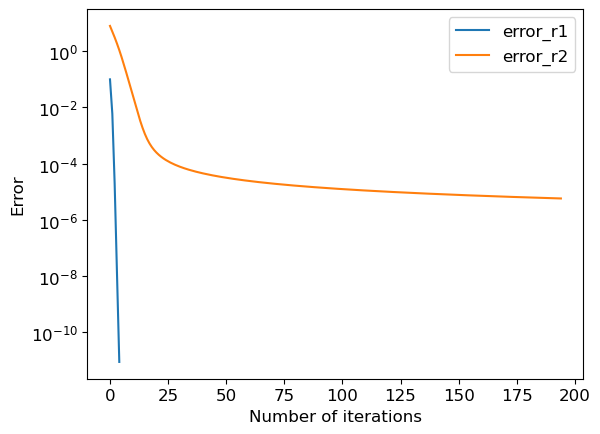

In [ ]:
# your code goes here





# This code is required for the autofeedback- don't delete it!
fighand = plt.gca()

In [14]:
runtest(['test_double_root', 'test_df_double_root', 'test_roots', 'test_errors', 'test_plot'])

Function, double_root is correct!              


Function, df_double_root is correct!              


Variable r1 is correct!              


Variable r2 is correct!              


Variable error_r1 is correct!              


Variable error_r2 is correct!              


Dataset error_r1 plotted correctly!


Dataset error_r2 plotted correctly!


Plot is correct!


